In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


In [2]:
np.random.seed(42)
n_samples = 100

X1 = np.random.rand(n_samples) * 10
X2 = 2 * X1 + np.random.randn(n_samples)
X3 = -3 * X1 + 0.5 * X2 + np.random.randn(n_samples)

y = 3 * X1 + 2 * X2 + 0.5 * X3 + np.random.randn(n_samples) * 2

In [3]:
data = {
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'y': y
}
df = pd.DataFrame(data)
df.sample(5)

,X1,X2,X3,y
61,2.713490,5.104919,-5.401557,15.006759
92,7.607850,14.970313,-15.778440,45.070310
97,4.275410,8.891972,-8.370011,28.343711
91,7.132448,16.161689,-14.746641,46.372586
41,4.951769,8.734860,-10.724696,26.342146


In [4]:
features = df.drop(columns='y', axis=1)
target = df['y']

In [5]:
correlation_matrix = np.corrcoef(df.T)
correlation_matrix

array([[ 1.        ,  0.98815829, -0.98138408,  0.98861807],
       [ 0.98815829,  1.        , -0.95907914,  0.99516692],
       [-0.98138408, -0.95907914,  1.        , -0.95798293],
       [ 0.98861807,  0.99516692, -0.95798293,  1.        ]])

In [7]:
feature_names = df.columns
feature_names

Index(['X1', 'X2', 'X3', 'y'], dtype='object')

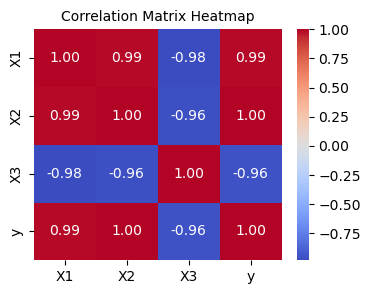

In [8]:
plt.figure(figsize=(4, 3))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            xticklabels=feature_names, yticklabels=feature_names)
plt.title("Correlation Matrix Heatmap", fontsize=10)
plt.show()


In [9]:
X_train, X_test, y_train, y_test = train_test_split(features, target, random_state= 42, test_size= 0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
simple_lr = LinearRegression()
ridge_lr = Ridge(alpha=0.1)
lasso_lr = Lasso(alpha=0.1)

In [21]:
simple_lr.fit(X_train, y_train)
print("Coefficients:", simple_lr.coef_)
print("Intercept:", simple_lr.intercept_)

ridge_lr.fit(X_train_scaled, y_train)
print("Coefficients:", ridge_lr.coef_)
print("Intercept:", ridge_lr.intercept_)

lasso_lr.fit(X_train_scaled, y_train)
print("Coefficients:", lasso_lr.coef_)
print("Intercept:", lasso_lr.intercept_)


Coefficients: [2.34768733 2.14509089 0.31177031]
Intercept: 0.14784911528930778
Coefficients: [ 6.72138773 12.2202386   1.57403461]
Intercept: 28.157106079566894
Coefficients: [ 4.40730929 12.90247982 -0.        ]
Intercept: 28.157106079566894


In [12]:
y_train_pred_simple = simple_lr.predict(X_train)
y_test_pred_simple = simple_lr.predict(X_test)

y_train_pred_ridge = ridge_lr.predict(X_train_scaled)
y_test_pred_ridge = ridge_lr.predict(X_test_scaled)

y_train_pred_lasso = lasso_lr.predict(X_train_scaled)
y_test_pred_lasso = lasso_lr.predict(X_test_scaled)

In [13]:
def calculate_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, mae, r2

In [14]:
train_metrics_simple = calculate_metrics(y_train, y_train_pred_simple)
test_metrics_simple = calculate_metrics(y_test, y_test_pred_simple)

train_metrics_ridge = calculate_metrics(y_train, y_train_pred_ridge)
test_metrics_ridge = calculate_metrics(y_test, y_test_pred_ridge)

train_metrics_lasso = calculate_metrics(y_train, y_train_pred_lasso)
test_metrics_lasso = calculate_metrics(y_test, y_test_pred_lasso)

In [17]:
def calculate_vaf(y_true, y_pred):
    var_y_true = np.var(y_true)
    vaf = (1 - (np.var(y_true - y_pred) / var_y_true)) * 100
    return vaf

In [18]:
vaf_simple_train = calculate_vaf(y_train, y_train_pred_simple)
vaf_simple_test = calculate_vaf(y_test, y_test_pred_simple)

In [19]:
vaf_ridge_train = calculate_vaf(y_train, y_train_pred_ridge)
vaf_ridge_test = calculate_vaf(y_test, y_test_pred_ridge)

In [20]:
vaf_lasso_train = calculate_vaf(y_train, y_train_pred_lasso)
vaf_lasso_test = calculate_vaf(y_test, y_test_pred_lasso)

In [22]:
results_data = {
    'Metric': ['MSE', 'MAE', 'R-squared', 'VAF'],
    'LR (Train)': list(train_metrics_simple) + [vaf_simple_train],
    'LR (Test)': list(test_metrics_simple) + [vaf_simple_test],
    'RR (Train)': list(train_metrics_ridge) + [vaf_ridge_train],
    'RR (Test)': list(test_metrics_ridge) + [vaf_ridge_test],
    'Lasso (Train)': list(train_metrics_lasso) + [vaf_lasso_train],
    'Lasso (Test)': list(test_metrics_lasso) + [vaf_lasso_test]  # Include Lasso results
}

results_df = pd.DataFrame(results_data)

results_df

,Metric,LR (Train),LR (Test),RR (Train),RR (Test),Lasso (Train),Lasso (Test)
0,MSE,2.786593,1.446386,2.790915,1.512493,2.892156,1.933790
1,MAE,1.357591,0.861089,1.358098,0.874015,1.372445,1.033883
2,R-squared,0.990849,0.995886,0.990835,0.995698,0.990503,0.994499
3,VAF,99.084925,99.590986,99.083505,99.575768,99.050260,99.488854
